Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
np.random.seed(123)

n_trials = 15
x = np.arange(0, n_trials)

mu_hr, sigma_hr = 75.0, 3.0
mu_bel, sigma_bel = 80.0, 3.0
alpha, beta = -10.0, 5.0
heart_rates = np.random.normal(mu_hr, sigma_hr, n_trials) + np.sin(x * 0.1)
tones_bpm = np.arange(10, 200)
tones_bias = np.arange(-40, 40)
listening_tones = np.linspace(20, 150, n_trials)
deciding_tones = np.linspace(20, 150, n_trials)

f = interp1d(x, heart_rates, kind="cubic")
new_heart_rate = f(np.arange(0, n_trials - 1, 0.001))

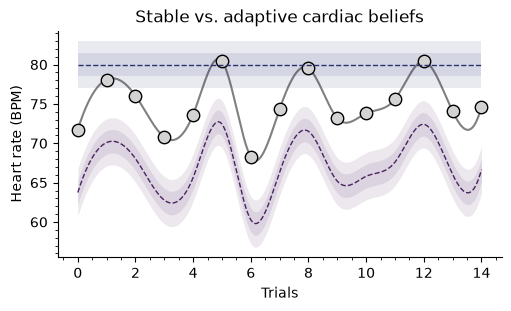

In [3]:
_, axs = plt.subplots(figsize=(5, 3))

axs.fill_between(
    x=np.arange(0, n_trials - 1, 0.001),
    y1=new_heart_rate - 8.0 - 0.5 * sigma_bel,
    y2=new_heart_rate - 8.0 + 0.5 * sigma_bel,
    color="#4a2262",
    alpha=0.1,
    linewidth=0,
)
axs.fill_between(
    x=np.arange(0, n_trials - 1, 0.001),
    y1=new_heart_rate - 8.0 - sigma_bel,
    y2=new_heart_rate - 8.0 + sigma_bel,
    color="#4a2262",
    alpha=0.1,
    linewidth=0,
)
axs.plot(
    np.arange(0, n_trials - 1, 0.001),
    new_heart_rate - 8.0,
    linestyle="--",
    linewidth=1,
    color="#4a2262",
)


axs.fill_between(
    x=x,
    y1=mu_bel - 0.5 * sigma_bel,
    y2=mu_bel + 0.5 * sigma_bel,
    color="#2c3071",
    alpha=0.1,
    linewidth=0,
)
axs.fill_between(
    x=x,
    y1=mu_bel - sigma_bel,
    y2=mu_bel + sigma_bel,
    color="#2c3071",
    alpha=0.1,
    linewidth=0,
)
axs.plot(
    x,
    np.ones(n_trials) * mu_bel,
    linestyle="--",
    linewidth=1,
    color="#2c3071",
)

axs.scatter(
    x,
    heart_rates,
    s=80,
    color="lightgrey",
    edgecolor="k",
)
axs.plot(np.arange(0, n_trials - 1, 0.001), new_heart_rate, color="grey", zorder=0)

axs.set(title="Stable vs. adaptive cardiac beliefs", ylabel="Heart rate (BPM)")
axs.minorticks_on()

axs.set(xlabel="Trials")
sns.despine()
plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_illustration.svg")